# PET-проект - Цены на недвижимость Москвы

**

В проекте я беру на себя роль аналитика платформы объявлений о недвижимости (тип ЦИАН / Авито)
и решаю две самостоятельные задачи регрессии:

1. **Оценка цены продажи квартиры** - по данным реальных сделок (реестр сделок, 1 квартал 2026).
2. **Рекомендация арендной ставки** - по объявлениям об аренде квартир в Москве.

Зачем это бизнесу: когда человек выставляет квартиру (на продажу или в аренду), он часто не знает,
какую цену поставить. Если цена завышена - объявление висит месяцами, если занижена - теряются деньги.
Поэтому платформе полезно автоматически подсказывать «рыночную» цену по характеристикам квартиры.

## Импорты

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
!pip install category_encoders
from category_encoders import TargetEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.2 MB/s eta 0:00:00


## Чем меряем качество

Задача - регрессия, поэтому смотрим на привычные метрики: R^2 (какую долю разброса цены объясняет
модель), RMSE и MAE (насколько в среднем ошибаемся). Берём готовые функции из sklearn и считаем
их прямо на месте после каждой модели. Целевую переменную (цену) логарифмируем, поэтому RMSE и MAE будут
в логарифмической шкале.

# Задача 1. Цена продажи квартиры

Данные - реестр сделок купли-продажи квартир по Москве за 1 квартал 2026 года.
Целевая переменная - deal_price (цена сделки в рублях).

## 1.1 Загрузка и первый взгляд

In [ ]:
deals = pd.read_csv('moscow_flats_deals_2026_q1.csv')
print('Размер:', deals.shape)
deals.head()

Размер: (23824, 20)


,number,okato,region_code,district,city,quarter_cad_number,street,realestate_type_code,wall_material_code,year_build,floor,purpose_code,area,period_start_date,deal_price,currency,doc_type,region_code_num,realestate_type_num,purpose_code_str
0,1,4.500000e+10,77.0,муниципальный округ Богородское,NaN,77:03:0002020,Погонный,2001003000,061001001001,1961,2,206001000000,11.7,2026-01-01,4150000.00,рубль,ДКП,77.0,2001003000,206001000000
1,1,4.500000e+10,77.0,муниципальный округ Головинский,NaN,77:09:0001026,Онежская,2001003000,061001001001,1956,3,206002000000,20.1,2026-01-01,5000000.00,рубль,ДКП,77.0,2001003000,206002000000
2,2,4.500000e+10,77.0,муниципальный округ Коммунарка,NaN,77:17:0120316,Эдварда Грига,2001003000,061001006001;061001007000,2025,-1,206001000000,260.9,2026-01-01,26640135.00,рубль,ДКП,77.0,2001003000,206001000000
3,1,4.500000e+10,77.0,муниципальный округ Мещанский,NaN,77:01:0003055,Напрудный,2001003000,061001001001,1905,1,206001000000,13.2,2026-01-01,5398000.00,рубль,ДКП,77.0,2001003000,206001000000
4,1,4.500000e+10,77.0,муниципальный округ Строгино,NaN,77:08:0008006,Неманский,2001003000,NaN,NaN,5,206002000000,17.5,2026-01-01,2497859.69,рубль,ДКП,77.0,2001003000,206002000000


In [ ]:
deals.dtypes

,0
number,int64
okato,float64
region_code,float64
district,object
city,object
quarter_cad_number,object
street,object
realestate_type_code,int64
wall_material_code,object
year_build,object


In [ ]:
deals.describe()

,number,okato,region_code,realestate_type_code,purpose_code,area,deal_price,region_code_num,realestate_type_num,purpose_code_str
count,23824.000000,2.382300e+04,23824.0,2.382400e+04,2.382400e+04,23824.000000,2.382400e+04,23824.0,2.382400e+04,2.382400e+04
mean,2.155264,4.528241e+10,77.0,2.001003e+09,2.060018e+11,105.146389,4.029207e+07,77.0,2.001003e+09,2.060018e+11
std,9.055447,2.132673e+07,0.0,0.000000e+00,3.993521e+05,431.886481,2.216795e+08,0.0,0.000000e+00,3.993521e+05
min,1.000000,4.500000e+10,77.0,2.001003e+09,2.060010e+11,1.300000,1.000000e+00,77.0,2.001003e+09,2.060010e+11
25%,1.000000,4.527756e+10,77.0,2.001003e+09,2.060020e+11,36.000000,1.050000e+07,77.0,2.001003e+09,2.060020e+11
50%,1.000000,4.528358e+10,77.0,2.001003e+09,2.060020e+11,51.200000,1.550000e+07,77.0,2.001003e+09,2.060020e+11
75%,1.000000,4.529358e+10,77.0,2.001003e+09,2.060020e+11,75.200000,2.500000e+07,77.0,2.001003e+09,2.060020e+11
max,417.000000,4.529858e+10,77.0,2.001003e+09,2.060020e+11,15175.100000,1.061867e+10,77.0,2.001003e+09,2.060020e+11


## 1.2 EDA - смотрим на данные

Сначала пропуски и дубликаты, потом целевую переменную и основные признаки.

пропуски по столбцам (в процентах)

In [ ]:
missing = (deals.isnull().mean() * 100).round(1)
missing[missing > 0].sort_values(ascending=False)

,0
district,97.3
city,8.1
wall_material_code,2.6
year_build,2.3
floor,2.2
street,1.9


Видим, что district пустой почти у всех строк (97%), поэтому как признак он бесполезен.
Зато quarter_cad_number (кадастровый квартал) заполнен везде - это, по сути, метка района/места,
её мы используем дальше. floor, year_build, wall_material_code имеют немного пропусков (2–3%).

In [ ]:
print('Полных дубликатов:', deals.duplicated().sum())
deals = deals.drop_duplicates().reset_index(drop=True)
print('После удаления дубликатов:', deals.shape)

Полных дубликатов: 0
После удаления дубликатов: (23824, 20)


распределение цены сделки (как есть)

Text(0.5, 0, 'рубли')

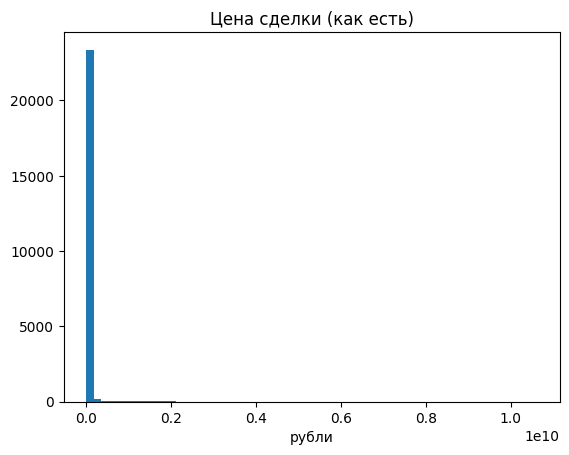

In [ ]:
plt.hist(deals['deal_price'], bins=60)
plt.title('Цена сделки (как есть)')
plt.xlabel('рубли')

то же распределение, но в логарифме

минимум : 1.0
медиана : 15500000.0
максимум: 10618671018.2


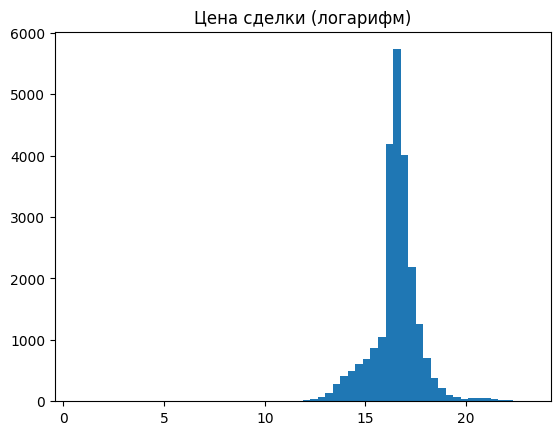

In [ ]:
plt.hist(np.log1p(deals['deal_price']), bins=60)
plt.title('Цена сделки (логарифм)')
print('минимум :', deals['deal_price'].min())
print('медиана :', deals['deal_price'].median())
print('максимум:', deals['deal_price'].max())

Распределение сильно скошено вправо: есть копеечные значения (например, 1 рубль - это явно
технические записи) и гигантские суммы (целые здания/элитка). В логарифме картина становится почти
нормальной (колоколом). Поэтому дальше целевую переменную мы будем логарифмировать, а перед этим
отрежем явные выбросы по цене.

распределение площади

99% квантиль площади: 1220.9 м2


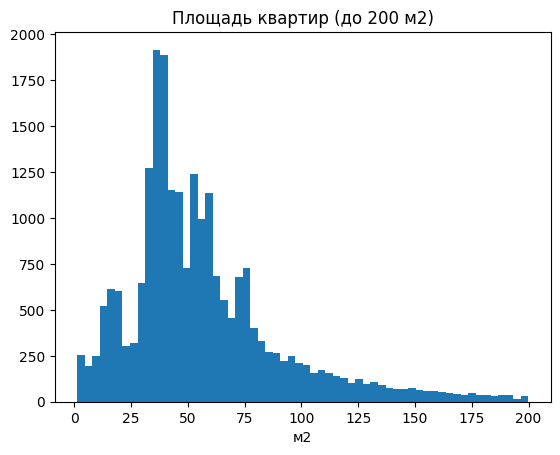

In [ ]:
plt.hist(deals.loc[deals['area'] < 200, 'area'], bins=60)
plt.title('Площадь квартир (до 200 м2)')
plt.xlabel('м2')
print('99% квантиль площади:', round(deals['area'].quantile(0.99), 1), 'м2')

корреляции числовых признаков

Text(0.5, 1.0, 'Корреляции (задача 1)')

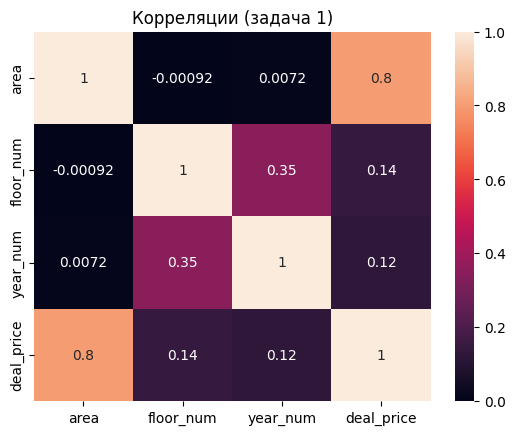

In [ ]:
tmp = deals.copy()
tmp['floor_num'] = pd.to_numeric(tmp['floor'], errors='coerce')
tmp['year_num'] = pd.to_numeric(tmp['year_build'], errors='coerce')
corr = tmp[['area', 'floor_num', 'year_num', 'deal_price']].corr()
sns.heatmap(corr, annot=True)
plt.title('Корреляции (задача 1)')


Ожидаемо сильнее всего с ценой связана площадь. Этаж и год постройки сами по себе слабо коррелируют
с ценой - но это не значит, что они бесполезны: деревья и ансамбли умеют ловить нелинейные зависимости.

## 1.3 Предобработка

Делаем по шагам:
1. отрезаем выбросы по цене и площади
2. превращаем floor и year_build в числа
3. считаем возраст дома building_age
4. расшифровываем код материала стен в понятную категорию
5. логарифмируем цену

In [ ]:
print('до чистки:', deals.shape[0])
deals = deals[(deals['deal_price'] >= 1_000_000) & (deals['deal_price'] <= 100_000_000)]
deals = deals[(deals['area'] >= 10) & (deals['area'] <= 300)]
print('после чистки:', deals.shape[0])

до чистки: 23824
после чистки: 21862


floor и year_build в числа (нечисловые значения станут NaN)

In [ ]:
deals['floor'] = pd.to_numeric(deals['floor'], errors='coerce')
deals['year_build'] = pd.to_numeric(deals['year_build'], errors='coerce')
deals.loc[(deals['year_build'] < 1900) | (deals['year_build'] > 2026), 'year_build'] = np.nanы
deals['building_age'] = 2026 - deals['year_build']
deals[['floor', 'year_build', 'building_age']].describe()

,floor,year_build,building_age
count,21609.000000,21610.000000,21610.000000
mean,7.587626,1992.769181,33.230819
std,6.749417,25.661773,25.661773
min,-5.000000,1900.000000,0.000000
25%,3.000000,1971.000000,8.000000
50%,6.000000,1996.000000,30.000000
75%,11.000000,2018.000000,55.000000
max,61.000000,2026.000000,126.000000


материал стен: коды вида '061001007001' расшифровываем словарём. Если в строке несколько кодов через ';', берём первый (основной).

In [ ]:
wall_map = {
    '061001007001': 'Монолит',
    '061001007003': 'Монолит',
    '061001007000': 'Монолит',
    '061001007004': 'Монолит-кирпич',
    '061001001001': 'Панель',
    '061001003000': 'Кирпич',
    '061001006001': 'Блок',
    '061001006002': 'Блок',
    '061001005000': 'Сборный ж/б',
}

def wall_name(code):
    if pd.isna(code):
        return 'Неизвестно'
    first = str(code).split(';')[0].strip()
    return wall_map.get(first, 'Прочее')

deals['wall_material'] = deals['wall_material_code'].apply(wall_name)
deals['wall_material'].value_counts()

,count
wall_material,
Монолит,11050
Панель,4077
Монолит-кирпич,2352
Блок,1790
Кирпич,1296
Сборный ж/б,590
Прочее,476
Неизвестно,231


Text(0.5, 0, 'число сделок')

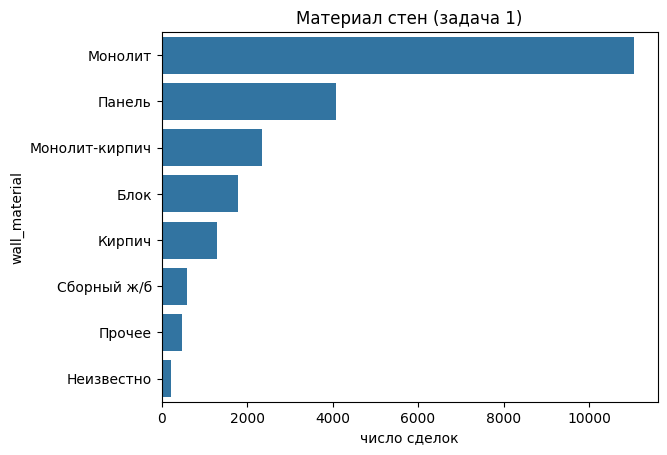

In [ ]:
wc = deals['wall_material'].value_counts()
sns.barplot(x=wc.values, y=wc.index)
plt.title('Материал стен (задача 1)')
plt.xlabel('число сделок')

логарифм цены

Text(0.5, 1.0, 'Логарифм цены сделки')

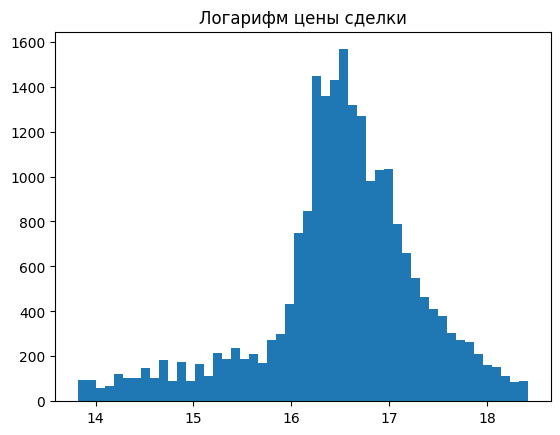

In [ ]:
deals['log_price'] = np.log1p(deals['deal_price'])
plt.hist(deals['log_price'], bins=50)
plt.title('Логарифм цены сделки')

## 1.4 Признаки, кодирование и масштабирование

Признаки для модели:
- числовые: area, floor, building_age;
- категориальные (мало значений) - wall_material: кодируем через get_dummies;
- кадастровый квартал quarter_cad_number (очень много значений) - кодируем через TargetEncoder

TargetEncoder - это то, чего на семинарах не было. Идея простая: вместо тысячи столбцов one-hot
заменяем каждый квартал одним числом - средней ценой по этому кварталу. Важно обучать
кодировщик только на train, иначе будет утечка (тест «подсмотрит» свои цены).

Масштабируем числовые признаки StandardScaler'ом (нужно для KNN, Ridge, SVR; деревьям не мешает).
Пропуски заполняем SimpleImputer (медиана для чисел).

In [ ]:
data = deals.dropna(subset=['log_price']).copy()
X = data[['area', 'floor', 'building_age', 'wall_material', 'quarter_cad_number']]
y = data['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=797)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (17489, 5)  test: (4373, 5)


TargetEncoder для кадастрового квартала (обучаем только на train)

In [ ]:
te = TargetEncoder()
te.fit(X_train[['quarter_cad_number']], y_train)
X_train['quarter'] = te.transform(X_train[['quarter_cad_number']])['quarter_cad_number']
X_test['quarter'] = te.transform(X_test[['quarter_cad_number']])['quarter_cad_number']
X_train[['quarter_cad_number', 'quarter']].head()

,quarter_cad_number,quarter
3139,77:07:0015005,16.318923
22928,77:17:0150111,16.476752
13622,77:01:0006040,16.462528
11161,77:08:0003006,16.580773
7872,77:09:0005007,16.779948


числовые признаки: пропуски (медиана) + масштабирование

In [ ]:
numcols = ['area', 'floor', 'building_age', 'quarter']
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

train_num = scaler.fit_transform(imputer.fit_transform(X_train[numcols]))
test_num = scaler.transform(imputer.transform(X_test[numcols]))
train_num = pd.DataFrame(train_num, columns=numcols, index=X_train.index)
test_num = pd.DataFrame(test_num, columns=numcols, index=X_test.index)

категориальный признак (материал стен): one-hot через get_dummies

In [ ]:
train_cat = pd.get_dummies(X_train['wall_material']).astype(int)
test_cat = pd.get_dummies(X_test['wall_material']).astype(int)
test_cat = test_cat.reindex(columns=train_cat.columns, fill_value=0)

X_train = pd.concat([train_num, train_cat], axis=1)
X_test = pd.concat([test_num, test_cat], axis=1)
features = list(X_train.columns)
print('итоговая матрица train:', X_train.shape)

итоговая матрица train: (17489, 12)


заодно посмотрим, какие признаки сильнее всего связаны с ценой (F-критерий, SelectKBest)

In [ ]:
skb = SelectKBest(score_func=f_regression, k='all')
skb.fit(X_train, y_train)
pd.Series(skb.scores_, index=features).sort_values(ascending=False).round(1)

,0
area,10312.1
quarter,3436.8
floor,1921.2
building_age,446.6
Блок,251.9
Монолит-кирпич,126.1
Прочее,88.8
Панель,82.3
Кирпич,52.6
Монолит,51.6


## 1.5 Обучаем модели и сравниваем

Берём шесть моделей разной природы (так мы сможем честно их сравнить):
линейная (Ridge), метрическая (KNN), дерево решений, случайный лес (бэггинг),
градиентный бустинг и метод опорных векторов (SVR). Плюс отдельно добавим нейросеть (она не из курса).
Для каждой коротко подбираем главный гиперпараметр и считаем метрики на тесте.

In [ ]:
results1 = []

1) Ridge (линейная модель с L2-регуляризацией) подберём alpha по кросс-валидации на train

In [ ]:
for a in [0.1, 1.0, 10.0, 100.0]:
    cv = cross_val_score(Ridge(alpha=a), X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    print('alpha =', a, ' CV MSE =', round(-cv.mean(), 4))

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('Ridge  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'Ridge', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

alpha = 0.1  CV MSE = 0.3385
alpha = 1.0  CV MSE = 0.3385
alpha = 10.0  CV MSE = 0.3385
alpha = 100.0  CV MSE = 0.3385
Ridge  R2 = 0.451  RMSE = 0.609  MAE = 0.427


2) KNN (метрический метод) подберём число соседей k по кросс-валидации

KNN  R2 = 0.618  RMSE = 0.508  MAE = 0.337


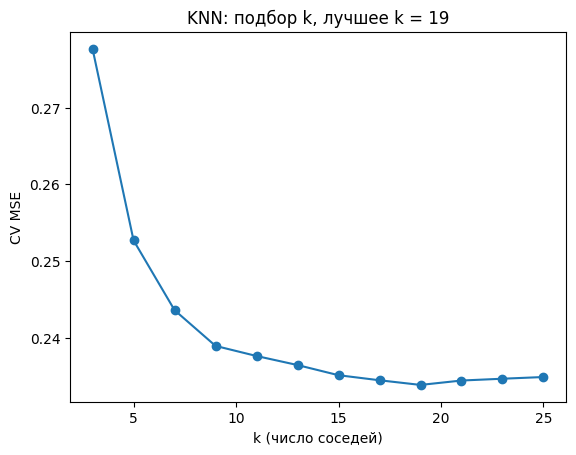

In [ ]:
ks = range(3, 26, 2)
cv_mse = []
for k in ks:
    cv = cross_val_score(KNeighborsRegressor(n_neighbors=k), X_train, y_train,
                         cv=5, scoring='neg_mean_squared_error')
    cv_mse.append(-cv.mean())

best_k = list(ks)[int(np.argmin(cv_mse))]
plt.plot(list(ks), cv_mse, marker='o')
plt.xlabel('k (число соседей)')
plt.ylabel('CV MSE')
plt.title('KNN: подбор k, лучшее k = ' + str(best_k))


knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('KNN  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'KNN (k=' + str(best_k) + ')', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

3) Дерево решений

Дерево  R2 = 0.609  RMSE = 0.514  MAE = 0.341


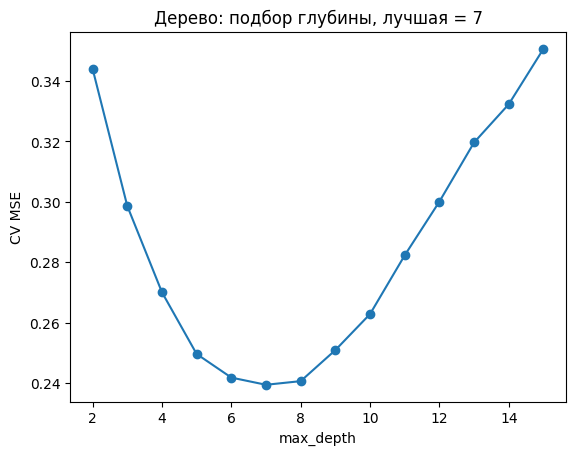

In [ ]:
depths = range(2, 16)
cv_mse = []
for d in depths:
    cv = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=797), X_train, y_train,
                         cv=5, scoring='neg_mean_squared_error')
    cv_mse.append(-cv.mean())

best_d = list(depths)[int(np.argmin(cv_mse))]
plt.plot(list(depths), cv_mse, marker='o')
plt.xlabel('max_depth')
plt.ylabel('CV MSE')
plt.title('Дерево: подбор глубины, лучшая = ' + str(best_d))


tree = DecisionTreeRegressor(max_depth=best_d, random_state=797)
tree.fit(X_train, y_train)
pred = tree.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('Дерево  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'Дерево (depth=' + str(best_d) + ')', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

4) Случайный лес (бэггинг) посмотрим, как ошибка зависит от числа деревьев

Случайный лес  R2 = 0.656  RMSE = 0.483  MAE = 0.317


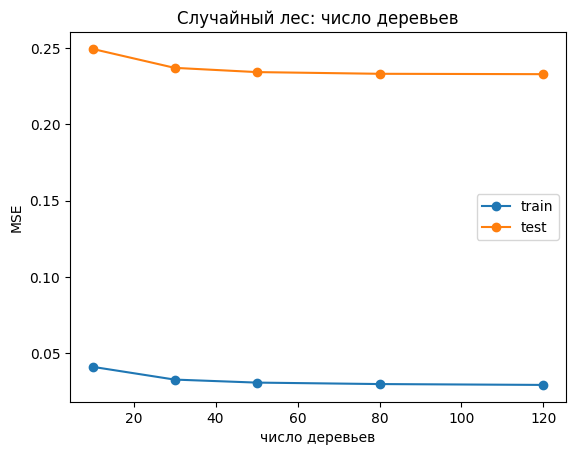

In [ ]:
ns = [10, 30, 50, 80, 120]
train_err = []
test_err = []
for n in ns:
    m = RandomForestRegressor(n_estimators=n, random_state=797)
    m.fit(X_train, y_train)
    train_err.append(mean_squared_error(y_train, m.predict(X_train)))
    test_err.append(mean_squared_error(y_test, m.predict(X_test)))

plt.plot(ns, train_err, marker='o', label='train')
plt.plot(ns, test_err, marker='o', label='test')
plt.xlabel('число деревьев')
plt.ylabel('MSE')
plt.title('Случайный лес: число деревьев')
plt.legend()


rf = RandomForestRegressor(n_estimators=100, random_state=797)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('Случайный лес  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'Случайный лес', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

5) Градиентный бустинг

In [ ]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=797)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('Градиентный бустинг  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'Градиентный бустинг', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

Градиентный бустинг  R2 = 0.661  RMSE = 0.479  MAE = 0.315


6) SVR (метод опорных векторов) SVR медленный на больших данных, поэтому обучаем на случайной подвыборке

In [ ]:
sample = X_train.sample(n=5000, random_state=797).index
svr = SVR(kernel='rbf', C=10)
svr.fit(X_train.loc[sample], y_train.loc[sample])
pred = svr.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('SVR  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'SVR', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

SVR  R2 = 0.627  RMSE = 0.502  MAE = 0.318


7) Нейросеть MLPRegressor простая полносвязная сеть: два скрытых слоя

Нейросеть  R2 = 0.627  RMSE = 0.502  MAE = 0.321


Text(0.5, 1.0, 'Нейросеть: кривая обучения (задача 1)')

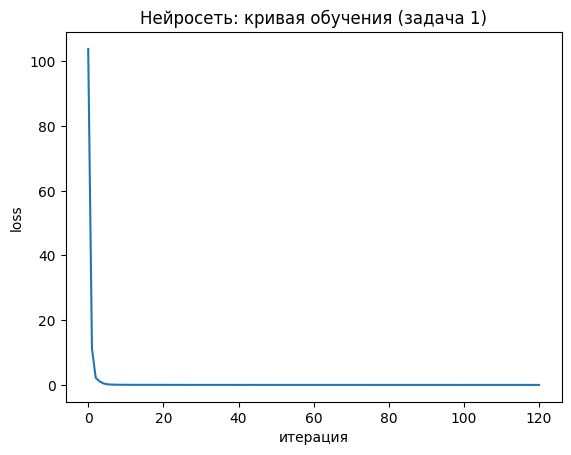

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=797)
mlp.fit(X_train, y_train)
pred = mlp.predict(X_test)

r2v = r2_score(y_test, pred)
rmsev = mean_squared_error(y_test, pred) ** 0.5
maev = mean_absolute_error(y_test, pred)
print('Нейросеть  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results1.append({'модель': 'Нейросеть (MLP)', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

plt.plot(mlp.loss_curve_)
plt.xlabel('итерация')
plt.ylabel('loss')
plt.title('Нейросеть: кривая обучения (задача 1)')


сводная таблица по задаче 1

In [ ]:
res1 = pd.DataFrame(results1).sort_values('R2', ascending=False).reset_index(drop=True)
res1.round(3)

,модель,R2,RMSE,MAE
0,Градиентный бустинг,0.661,0.479,0.315
1,Случайный лес,0.656,0.483,0.317
2,SVR,0.627,0.502,0.318
3,Нейросеть (MLP),0.627,0.502,0.321
4,KNN (k=19),0.618,0.508,0.337
5,Дерево (depth=7),0.609,0.514,0.341
6,Ridge,0.451,0.609,0.427


Text(0.5, 1.0, 'Задача 1: сравнение моделей по R2 (больше - лучше)')

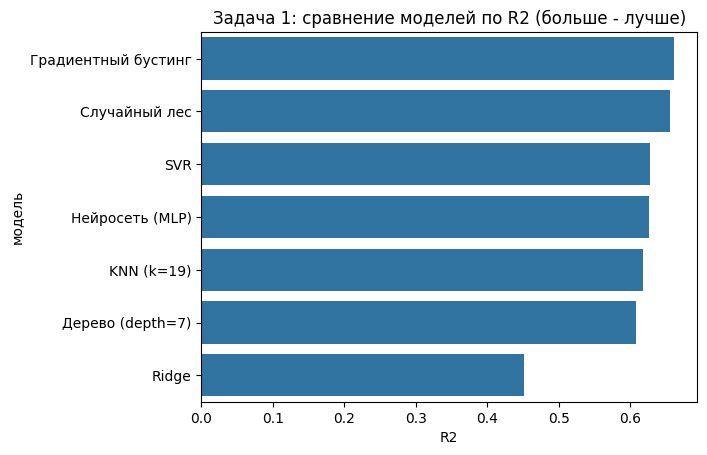

In [ ]:
sns.barplot(data=res1, x='R2', y='модель')
plt.title('Задача 1: сравнение моделей по R2 (больше - лучше)')


Вывод по задаче 1. Лучше всего себя показывают ансамбли деревьев (случайный лес и бустинг):
зависимость цены от признаков нелинейная, и деревья её ловят лучше линейной модели. Линейный Ridge заметно
отстаёт. Нейросеть работает примерно на уровне ансамблей, но без преимущества - для табличных данных это
нормально.

## 1.6 Какие признаки важны и анализ ошибок

важность признаков у случайного леса

,0
area,0.623
quarter,0.167
building_age,0.095
floor,0.084
Панель,0.008
Монолит,0.006
Прочее,0.004
Монолит-кирпич,0.003
Сборный ж/б,0.003
Кирпич,0.003


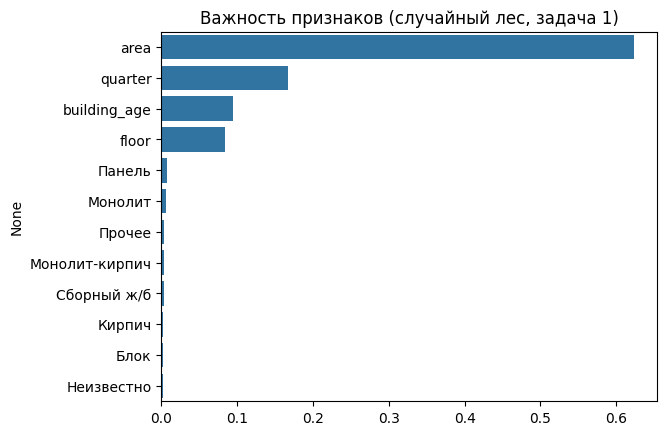

In [ ]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index)
plt.title('Важность признаков (случайный лес, задача 1)')

imp.round(3)

Главные предикторы - площадь и закодированный кадастровый квартал (по сути, район).
Это логично: цена квартиры в Москве определяется прежде всего размером и расположением.

Остатки симметрично разбросаны вокруг нуля и примерно колоколом - это признак того,
что модель не сильно смещена.

# Задача 2. Арендная ставка

Данные - объявления об аренде квартир в Москве. Целевая переменная - price (аренда, руб/мес).
Здесь есть гео-признаки (расстояние до метро, парка и т.д.) - о том, как мы их получили, ниже.

## 2.1 Как мы расширили данные (geopandas + osmnx, вне курса)

Исходный датасет аренды мы взяли с Kaggle (rent_apartments.csv, объявления по разным городам).
Сами по себе координаты квартиры модели мало что дают, поэтому мы сами дополнили данные
гео-признаками: расстояние до ближайшего метро и парка, число кафе и магазинов в радиусе 500 м.
Считали их по данным OpenStreetMap с помощью библиотек geopandas и osmnx - на семинарах этого не было.

Код ниже мы запускали отдельно (он скачивает объекты из OpenStreetMap и работает несколько минут),
а результат сохранили в rent_apartments_moscow_extended.csv, с которым дальше и работаем. Поэтому в
ноутбуке этот код приведён для понимания, но не выполняется.

python
import pandas as pd
import geopandas as gpd
import osmnx as ox

# 1. читаем исходный датасет с Kaggle и берём только Москву
df = pd.read_csv('rent_apartments.csv')
df = df[df['city'] == 'Москва'].reset_index(drop=True)
df['apt_id'] = df.index

# 2. делаем из координат гео-точки и переводим их в метры
apartments = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)
apartments = apartments.to_crs(apartments.estimate_utm_crs())

# 3. выгружаем объекты Москвы из OpenStreetMap
place = 'Moscow, Russia'
metro = ox.features_from_place(place, tags={'railway': 'subway_entrance'})[['geometry']].to_crs(apartments.crs)
parks = ox.features_from_place(place, tags={'leisure': 'park'})[['geometry']].to_crs(apartments.crs)
cafes = ox.features_from_place(place, tags={'amenity': ['cafe', 'restaurant']})[['geometry']].to_crs(apartments.crs)
shops = ox.features_from_place(place, tags={'shop': True})[['geometry']].to_crs(apartments.crs)

# 4. расстояние до ближайшего метро и парка (sjoin_nearest)
nearest_metro = gpd.sjoin_nearest(apartments[['apt_id', 'geometry']], metro, distance_col='dist_to_metro_m')
apartments['dist_to_metro_m'] = apartments['apt_id'].map(nearest_metro.groupby('apt_id')['dist_to_metro_m'].min())

nearest_park = gpd.sjoin_nearest(apartments[['apt_id', 'geometry']], parks, distance_col='dist_to_park_m')
apartments['dist_to_park_m'] = apartments['apt_id'].map(nearest_park.groupby('apt_id')['dist_to_park_m'].min())

# 5. число кафе и магазинов в радиусе 500 м (буфер вокруг квартиры)
buffers = apartments[['apt_id', 'geometry']].copy()
buffers['geometry'] = buffers.geometry.buffer(500)

cafes_near = gpd.sjoin(cafes, buffers, predicate='within')
apartments['cafes_500m'] = apartments['apt_id'].map(cafes_near.groupby('apt_id').size()).fillna(0).astype(int)

shops_near = gpd.sjoin(shops, buffers, predicate='within')
apartments['shops_500m'] = apartments['apt_id'].map(shops_near.groupby('apt_id').size()).fillna(0).astype(int)

# 6. убираем геометрию и сохраняем расширенный датасет
df_extended = pd.DataFrame(apartments.drop(columns='geometry'))
df_extended.to_csv('rent_apartments_moscow_extended.csv', index=False)


## 2.2 Загрузка и первый взгляд

In [ ]:
rent = pd.read_csv('rent_apartments_moscow_extended.csv')
print('Размер:', rent.shape)
rent.head()

Размер: (9042, 35)


,object_type,type,rooms,level,kitchen_area,living_area,area,price_by_meter,price,material,...,agencyName,areaRating,city,remoute_from_center,build_oldest,apt_id,dist_to_metro_m,dist_to_park_m,cafes_500m,shops_500m
0,0,Многоквартирный дом,1,2/5,6.0,20.0,32.0,906.0,29000.0,Панель,...,Alexei,3.909155,Москва,11.075363,old,0,660.685384,248.864273,4,47
1,0,Многоквартирный дом,1,1/9,12.0,19.0,31.0,1548.0,48000.0,Панель,...,OLSNIP,4.029171,Москва,17.033073,old,1,870.329330,245.096693,3,41
2,0,Многоквартирный дом,1,5/9,11.2,17.3,38.9,1131.0,44000.0,Панель,...,Дмитрий,3.446412,Москва,10.463894,middle,2,530.749822,419.878608,5,56
3,0,Многоквартирный дом,3,8/17,10.0,56.0,75.0,933.0,70000.0,Панель,...,Андрей,4.261248,Москва,20.343743,old,3,637.211497,555.027495,4,71
4,0,Квартира,2,8/23,11.0,32.0,60.0,1633.0,98000.0,Монолит,...,MosArenda,3.828671,Москва,10.709396,new,4,619.656401,52.664227,6,45


In [ ]:
rent.describe()

,object_type,rooms,kitchen_area,living_area,area,price_by_meter,price,build_year,build_type,max_levels,...,enterances,longitude,latitude,areaRating,remoute_from_center,apt_id,dist_to_metro_m,dist_to_park_m,cafes_500m,shops_500m
count,9042.0,9042.000000,6755.000000,6431.000000,9042.000000,9042.000000,9.042000e+03,9042.000000,9042.0,9042.000000,...,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000
mean,0.0,2.150409,11.473812,44.623807,78.767950,1967.146760,1.657005e+05,1336.635258,0.0,36.743751,...,2.987503,37.582787,55.745166,3.838439,9.700976,4520.500000,924.025141,319.299691,23.718646,82.630281
std,0.0,1.217133,6.611359,38.882977,62.645529,13653.976454,5.996195e+05,929.307697,0.0,2583.096201,...,3.529132,0.118249,0.079496,0.196386,6.646519,2610.344901,1946.995641,341.415396,30.502495,62.553782
min,0.0,0.000000,2.000000,5.000000,10.000000,367.000000,1.400000e+04,0.000000,0.0,0.000000,...,0.000000,37.145930,55.500810,3.168778,0.504009,0.000000,11.302859,0.000000,0.000000,0.000000
25%,0.0,1.000000,8.000000,20.000000,40.000000,1053.000000,4.950000e+04,0.000000,0.0,0.000000,...,0.000000,37.524067,55.705073,3.749073,4.778255,2260.250000,317.247020,122.522158,3.000000,36.000000
50%,0.0,2.000000,10.000000,33.000000,58.000000,1434.500000,7.500000e+04,1966.000000,0.0,9.000000,...,2.000000,37.577355,55.750601,3.841749,8.684829,4520.500000,556.601382,226.384755,8.000000,66.000000
75%,0.0,3.000000,13.000000,50.000000,91.000000,2222.000000,2.000000e+05,2000.000000,0.0,16.000000,...,5.000000,37.640137,55.787971,3.922360,13.671984,6780.750000,909.537607,391.865893,34.000000,117.000000
max,0.0,10.000000,100.000000,640.000000,811.000000,966667.000000,4.500000e+07,2021.000000,0.0,245633.000000,...,27.000000,37.973898,56.031337,4.627057,41.565229,9041.000000,22429.842503,4952.102600,151.000000,368.000000


## 2.3 EDA

In [ ]:
missing = (rent.isnull().mean() * 100).round(1)
missing[missing > 0].sort_values(ascending=False)

,0
living_area,28.9
kitchen_area,25.3
material,0.2


Через isnull пропусков почти не видно, но это обманчиво: в этом датасете «нет данных» часто записано
строкой '0' (так бывает при выгрузке из баз данных). Это поправим в предобработке.

распределение арендной цены (как есть)

Text(0.5, 1.0, 'Аренда (как есть)')

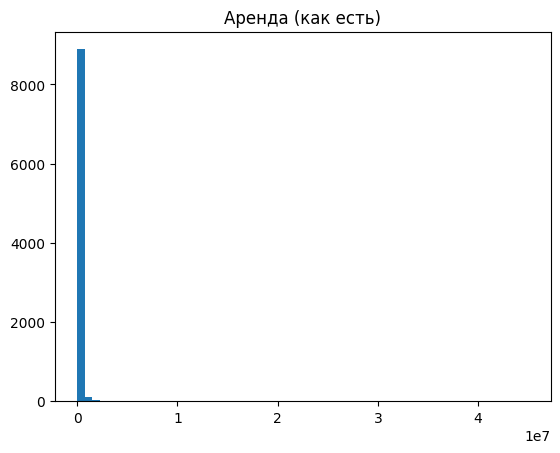

In [ ]:
plt.hist(rent['price'], bins=60)
plt.title('Аренда (как есть)')


то же в логарифме

медиана аренды: 75000.0


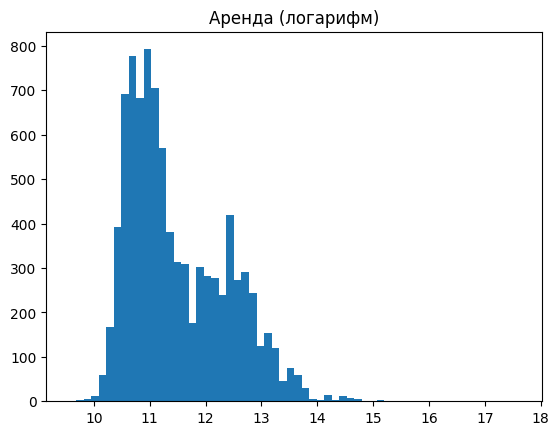

In [ ]:
plt.hist(np.log1p(rent['price']), bins=60)
plt.title('Аренда (логарифм)')


print('медиана аренды:', rent['price'].median())

корреляции числовых признаков

Text(0.5, 1.0, 'Корреляции (задача 2)')

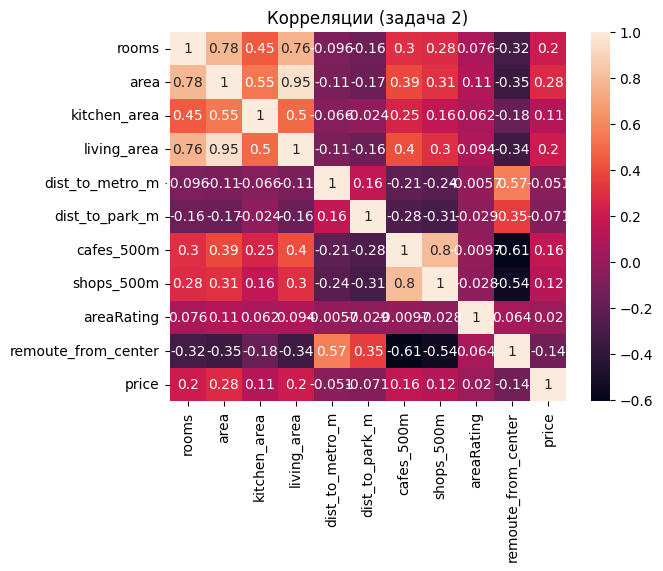

In [ ]:
cols = ['rooms', 'area', 'kitchen_area', 'living_area', 'dist_to_metro_m',
        'dist_to_park_m', 'cafes_500m', 'shops_500m', 'areaRating',
        'remoute_from_center', 'price']
sns.heatmap(rent[cols].corr(), annot=True)
plt.title('Корреляции (задача 2)')


Сильнее всего с ценой связана площадь, хотя даже её линейная корреляция умеренная (около 0.28) -
зависимость нелинейная. Из признаков расположения заметнее всего удалённость от центра
(remoute_from_center). А вот areaRating и расстояние до метро линейно с ценой почти не связаны
(коэффициенты близки к нулю) - это не значит, что место не важно: ниже увидим, что у деревьев
расположение всё равно один из главных факторов (через удалённость от центра).

## 2.4 Предобработка

Шаги:
1. меняем строковые '0' на пропуски (NaN)
2. убираем столбец build_type - он целиком равен '0' (нет информации)
3. разбираем level («этаж/всего этажей») на два числа
4. считаем несколько новых признаков
5. отрезаем выбросы по цене и площади, логарифмируем цену

'0' -> NaN в тех колонках, где это маркер "нет данных"

In [ ]:
zero_cols = ['build_serias', 'rubbish_chute', 'heating', 'gas', 'build_walls', 'build_overlap']
for c in zero_cols:
    rent[c] = rent[c].replace('0', np.nan)
rent['build_year'] = rent['build_year'].replace(0, np.nan)

rent = rent.drop(columns=['build_type'])
print('пропусков в build_year:', rent['build_year'].isna().sum())

пропусков в build_year: 2945


разбираем level "8/23" -> этаж 8, всего этажей 23

In [ ]:
parts = rent['level'].astype(str).str.split('/')

rent['floor'] = parts.str[0]
rent['total_floors'] = parts.str[1]

rent['floor'] = pd.to_numeric(rent['floor'], errors='coerce')
rent['total_floors'] = pd.to_numeric(rent['total_floors'], errors='coerce')

rent['floor_ratio'] = rent['floor'] / rent['total_floors']

rent[['level', 'floor', 'total_floors', 'floor_ratio']].head()

,level,floor,total_floors,floor_ratio
0,2/5,2,5,0.400000
1,1/9,1,9,0.111111
2,5/9,5,9,0.555556
3,8/17,8,17,0.470588
4,8/23,8,23,0.347826


новые признаки

In [ ]:
rent['building_age'] = 2026 - rent['build_year']
rent['room_area'] = rent['area'] / rent['rooms'].replace(0, 1)
rent['kitchen_ratio'] = rent['kitchen_area'] / rent['area']

выбросы по цене (1%..99%) и площади, затем логарифм

In [ ]:
lo = rent['price'].quantile(0.01)
hi = rent['price'].quantile(0.99)
print('до чистки:', rent.shape[0])
rent = rent[(rent['price'] >= lo) & (rent['price'] <= hi)]
rent = rent[(rent['area'] >= 10) & (rent['area'] <= 300)]
print('после чистки:', rent.shape[0])

rent['log_price'] = np.log1p(rent['price'])

до чистки: 9042
после чистки: 8798


## 2.5 Признаки, кодирование, масштабирование

Здесь признака с тысячей категорий нет, поэтому TargetEncoder не нужен - категориальные кодируем
обычным get_dummies. Числовые масштабируем и заполняем пропуски, как и в первой задаче.

In [ ]:
numcols2 = ['rooms', 'area', 'kitchen_area', 'living_area', 'dist_to_metro_m', 'dist_to_park_m',
            'cafes_500m', 'shops_500m', 'areaRating', 'remoute_from_center',
            'building_age', 'room_area', 'kitchen_ratio', 'floor_ratio', 'floor', 'total_floors']
catcols2 = ['material', 'build_walls', 'rubbish_chute', 'heating', 'gas', 'build_oldest']

data2 = rent.dropna(subset=['log_price']).copy()
X2 = data2[numcols2 + catcols2]
y2 = data2['log_price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=797)
print('train:', X_train2.shape, ' test:', X_test2.shape)

train: (7038, 22)  test: (1760, 22)


числовые: пропуски (медиана) + масштабирование

In [ ]:
imputer2 = SimpleImputer(strategy='median')
scaler2 = StandardScaler()

train_num2 = scaler2.fit_transform(imputer2.fit_transform(X_train2[numcols2]))
test_num2 = scaler2.transform(imputer2.transform(X_test2[numcols2]))
train_num2 = pd.DataFrame(train_num2, columns=numcols2, index=X_train2.index)
test_num2 = pd.DataFrame(test_num2, columns=numcols2, index=X_test2.index)

train_cat2 = pd.get_dummies(X_train2[catcols2].fillna('нет данных').astype(str)).astype(int)
test_cat2 = pd.get_dummies(X_test2[catcols2].fillna('нет данных').astype(str)).astype(int)
test_cat2 = test_cat2.reindex(columns=train_cat2.columns, fill_value=0)

X_train2 = pd.concat([train_num2, train_cat2], axis=1)
X_test2 = pd.concat([test_num2, test_cat2], axis=1)
features2 = list(X_train2.columns)
print('итоговая матрица train:', X_train2.shape)

итоговая матрица train: (7038, 48)


## 2.6 Модели и сравнение

Тот же набор из шести моделей разной природы плюс нейросеть.

In [ ]:
results2 = []

1) Ridge

In [ ]:
for a in [0.1, 1.0, 10.0, 100.0]:
    cv = cross_val_score(Ridge(alpha=a), X_train2, y_train2, cv=5, scoring='neg_mean_squared_error')
    print('alpha =', a, ' CV MSE =', round(-cv.mean(), 4))

ridge2 = Ridge(alpha=1.0)
ridge2.fit(X_train2, y_train2)
pred = ridge2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('Ridge  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'Ridge', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

alpha = 0.1  CV MSE = 0.068
alpha = 1.0  CV MSE = 0.068
alpha = 10.0  CV MSE = 0.068
alpha = 100.0  CV MSE = 0.0681
Ridge  R2 = 0.899  RMSE = 0.26  MAE = 0.199


2) KNN

KNN  R2 = 0.903  RMSE = 0.255  MAE = 0.192


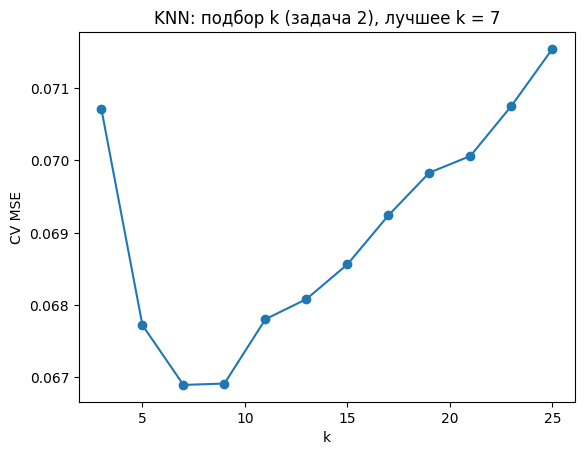

In [ ]:
ks = range(3, 26, 2)
cv_mse = []
for k in ks:
    cv = cross_val_score(KNeighborsRegressor(n_neighbors=k), X_train2, y_train2,
                         cv=5, scoring='neg_mean_squared_error')
    cv_mse.append(-cv.mean())

best_k = list(ks)[int(np.argmin(cv_mse))]
plt.plot(list(ks), cv_mse, marker='o')
plt.xlabel('k')
plt.ylabel('CV MSE')
plt.title('KNN: подбор k (задача 2), лучшее k = ' + str(best_k))


knn2 = KNeighborsRegressor(n_neighbors=best_k)
knn2.fit(X_train2, y_train2)
pred = knn2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('KNN  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'KNN (k=' + str(best_k) + ')', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

3) Дерево

Дерево  R2 = 0.902  RMSE = 0.257  MAE = 0.191


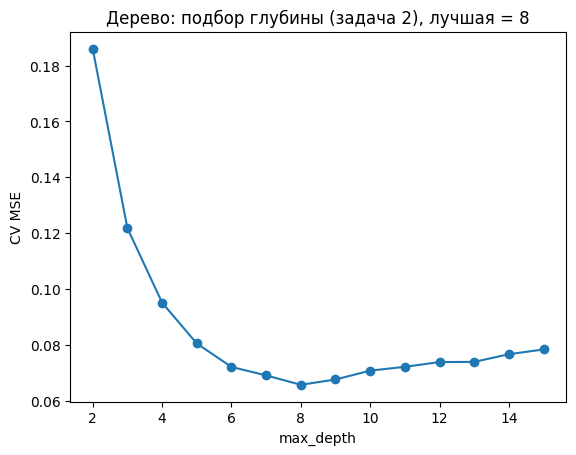

In [ ]:
depths = range(2, 16)
cv_mse = []
for d in depths:
    cv = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=797), X_train2, y_train2,
                         cv=5, scoring='neg_mean_squared_error')
    cv_mse.append(-cv.mean())

best_d = list(depths)[int(np.argmin(cv_mse))]
plt.plot(list(depths), cv_mse, marker='o')
plt.xlabel('max_depth')
plt.ylabel('CV MSE')
plt.title('Дерево: подбор глубины (задача 2), лучшая = ' + str(best_d))


tree2 = DecisionTreeRegressor(max_depth=best_d, random_state=797)
tree2.fit(X_train2, y_train2)
pred = tree2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('Дерево  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'Дерево (depth=' + str(best_d) + ')', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

4) Случайный лес

In [ ]:
rf2 = RandomForestRegressor(n_estimators=100, random_state=797)
rf2.fit(X_train2, y_train2)
pred = rf2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('Случайный лес  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'Случайный лес', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

Случайный лес  R2 = 0.942  RMSE = 0.197  MAE = 0.142


5) Градиентный бустинг

In [ ]:
gb2 = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=797)
gb2.fit(X_train2, y_train2)
pred = gb2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('Градиентный бустинг  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'Градиентный бустинг', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

Градиентный бустинг  R2 = 0.927  RMSE = 0.221  MAE = 0.166


6) SVR (на подвыборке)

In [ ]:
sample2 = X_train2.sample(n=5000, random_state=797).index
svr2 = SVR(kernel='rbf', C=10)
svr2.fit(X_train2.loc[sample2], y_train2.loc[sample2])
pred = svr2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('SVR  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'SVR', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

SVR  R2 = 0.915  RMSE = 0.239  MAE = 0.179


7) Нейросеть

In [ ]:
mlp2 = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=797)
mlp2.fit(X_train2, y_train2)
pred = mlp2.predict(X_test2)

r2v = r2_score(y_test2, pred)
rmsev = mean_squared_error(y_test2, pred) ** 0.5
maev = mean_absolute_error(y_test2, pred)
print('Нейросеть  R2 =', round(r2v, 3), ' RMSE =', round(rmsev, 3), ' MAE =', round(maev, 3))
results2.append({'модель': 'Нейросеть (MLP)', 'R2': r2v, 'RMSE': rmsev, 'MAE': maev})

Нейросеть  R2 = 0.906  RMSE = 0.251  MAE = 0.192


In [ ]:
res2 = pd.DataFrame(results2).sort_values('R2', ascending=False).reset_index(drop=True)
res2.round(3)

,модель,R2,RMSE,MAE
0,Случайный лес,0.942,0.197,0.142
1,Градиентный бустинг,0.927,0.221,0.166
2,SVR,0.915,0.239,0.179
3,Нейросеть (MLP),0.906,0.251,0.192
4,KNN (k=7),0.903,0.255,0.192
5,Дерево (depth=8),0.902,0.257,0.191
6,Ridge,0.899,0.260,0.199


Text(0.5, 1.0, 'Задача 2: сравнение моделей по R2')

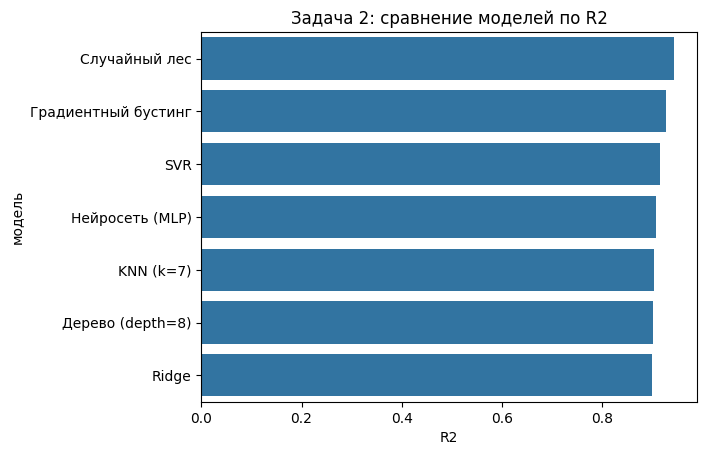

In [ ]:
sns.barplot(data=res2, x='R2', y='модель')
plt.title('Задача 2: сравнение моделей по R2')


важность признаков (случайный лес)

,0
area,0.682
remoute_from_center,0.174
total_floors,0.040
cafes_500m,0.019
dist_to_metro_m,0.008
build_oldest_new,0.008
dist_to_park_m,0.007
areaRating,0.006
shops_500m,0.006
material_Монолит,0.006


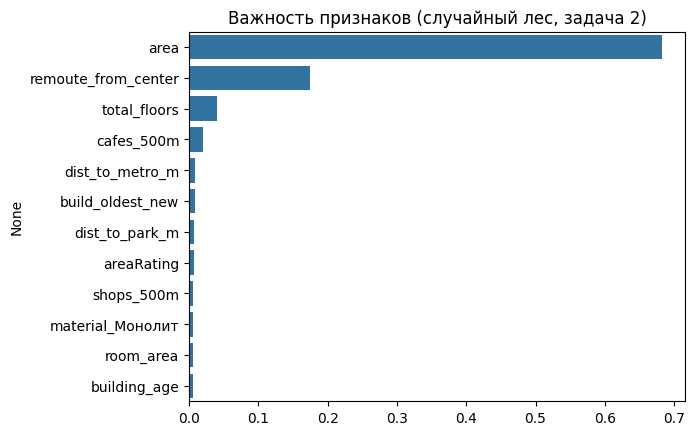

In [ ]:
imp2 = pd.Series(rf2.feature_importances_, index=features2).sort_values(ascending=False).head(12)
sns.barplot(x=imp2.values, y=imp2.index)
plt.title('Важность признаков (случайный лес, задача 2)')

imp2.round(3)

**Вывод по задаче 2.** Снова впереди ансамбли. По важности признаков после площади идёт
удалённость от центра, затем этажность дома и число кафе поблизости. То есть «где квартира»
почти так же важно для аренды, как «какая она по размеру».

# Итоги

Что делал. Решил две задачи регрессии для платформы недвижимости: предсказание цены продажи
и арендной ставки. В обеих прошел полный путь: разведочный анализ, чистка, генерация признаков,
обучение и честное сравнение нескольких моделей.

Главные результаты.
- Лучшие модели в обеих задачах - ансамбли деревьев (случайный лес и градиентный бустинг). Линейная
  модель и KNN заметно слабее, потому что зависимость цены от признаков нелинейная.
- Ключевые факторы цены - площадь и расположение (кадастровый квартал в сделках; удалённость
  от центра в аренде).

Бизнес-смысл. Такую модель платформа может встроить в форму подачи объявления: пользователь вводит
характеристики квартиры и сразу видит рекомендованную цену. Это сокращает время продажи/сдачи и снижает
число ошибочно оценённых объявлений.